In [1]:
import duckdb
import pandas as pd
print("Success!")

Success!


In [2]:
import pandas as pd
import plotly.express as px

In [6]:
# The 'r' before the path is crucial for Windows paths!
path = r'C:\Users\Utilisateur\Downloads\ecommerce_funnel_data.csv'

# Load the data from the specific location
df = pd.read_csv(path)

# Sort the funnel immediately
funnel_order = ['page_view', 'view_item', 'add_to_cart', 'purchase']
df['event_name'] = pd.Categorical(df['event_name'], categories=funnel_order, ordered=True)
df = df.sort_values('event_name')

# Display the result
df


,event_name,unique_users
0,page_view,269792
1,view_item,61252
3,add_to_cart,12545
2,purchase,4419


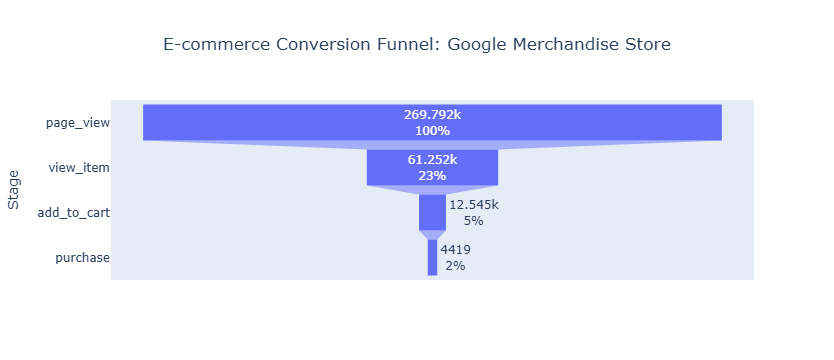

In [7]:
# 1. Create the figure using Plotly Express
# x='unique_users' defines the width of the bars
# y='event_name' defines the stages
fig = px.funnel(df, x='unique_users', y='event_name', 
                title='E-commerce Conversion Funnel: Google Merchandise Store',
                labels={'unique_users': 'Number of Users', 'event_name': 'Stage'})

# 2. Make it look professional
fig.update_traces(textinfo="value+percent initial")
fig.update_layout(title_x=0.5) # Centers the title

# 3. Show the chart
fig.show()